In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from skimage import exposure, morphology

# ===============================
# PART 1: UTILITY FUNCTIONS
# ===============================

def display_images(images, titles=None, cmap=None, figsize=(15, 10)):
    """Display multiple images in a grid"""
    n_images = len(images)
    if titles is None: 
        titles = ['Image (%d)' % i for i in range(1, n_images + 1)]
    fig = plt.figure(figsize=figsize)
    for n, (image, title) in enumerate(zip(images, titles)):
        a = fig.add_subplot(1, n_images, n+1)
        if image.ndim == 2:
            plt.gray()
        plt.imshow(image, cmap=cmap)
        a.set_title(title)
        a.set_axis_off()
    plt.tight_layout()
    return fig

def load_dataset(data_dir):
    """Load dataset and extract manufacturer info from filenames"""
    print(f"Loading dataset from {data_dir}")
    
    # Get all image files in the data directory
    all_image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
        all_image_paths.extend(glob(os.path.join(data_dir, ext)))
    
    if not all_image_paths:
        print(f"Error: No images found in {data_dir}")
        return None, None, None
        
    print(f"Found {len(all_image_paths)} images")
    
    # Extract manufacturer info and load images
    images = []
    labels = []
    paths = []
    
    # Define manufacturers
    manufacturers = ['Cofield', 'Depuy', 'Tornier', 'Zimmer']
    manufacturer_to_idx = {name: idx for idx, name in enumerate(manufacturers)}
    idx_to_manufacturer = {idx: name for idx, name in enumerate(manufacturers)}
    
    for img_path in tqdm(all_image_paths, desc="Loading images"):
        # Extract filename
        filename = os.path.basename(img_path)
        
        # Determine manufacturer from filename
        found_manufacturer = None
        for manufacturer in manufacturers:
            if manufacturer.lower() in filename.lower():
                found_manufacturer = manufacturer
                break
        
        if found_manufacturer is None:
            print(f"Warning: Could not determine manufacturer for {filename}, skipping")
            continue
        
        try:
            # Read the image
            img = cv2.imread(img_path)
            if img is None:
                print(f"Error reading image: {img_path}, skipping")
                continue
                
            # Convert BGR to RGB (OpenCV loads as BGR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Add to lists
            images.append(img)
            labels.append(manufacturer_to_idx[found_manufacturer])
            paths.append(img_path)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
    
    if not images:
        print("Error: No valid images were loaded")
        return None, None, None
    
    # Split data maintaining a list structure (don't convert to numpy array)
    from sklearn.model_selection import train_test_split
    
    # Create stratified splits
    train_images, test_images, train_labels, test_labels, train_paths, test_paths = train_test_split(
        images, labels, paths, test_size=0.3, random_state=42, stratify=labels
    )
    
    # Split test into validation and test
    val_images, test_images, val_labels, test_labels, val_paths, test_paths = train_test_split(
        test_images, test_labels, test_paths, test_size=0.7, random_state=42, stratify=test_labels
    )
    
    print(f"Train set: {len(train_images)} images")
    print(f"Validation set: {len(val_images)} images")
    print(f"Test set: {len(test_images)} images")
    
    return {
        'train_data': (train_images, train_labels, train_paths),
        'val_data': (val_images, val_labels, val_paths),
        'test_data': (test_images, test_labels, test_paths),
        'idx_to_manufacturer': idx_to_manufacturer,
        'manufacturer_to_idx': manufacturer_to_idx,
        'num_classes': len(manufacturers)
    }

# ===============================
# PART 2: IMPLANT DETECTION
# ===============================

def preprocess_bilateral(image, d=5, sigma_color=10, sigma_space=10):
    """Preprocess image using bilateral filter"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    return cv2.bilateralFilter(gray, d, sigma_color, sigma_space)

def preprocess_median_blur(image, kernel_size=3):
    """Preprocess image using median blur filter"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    return cv2.medianBlur(gray, kernel_size)

def find_circle(image, min_dimen=None):
    """
    Use Hough circles to detect the implant head.
    
    Returns:
        center_x, center_y, radius, success: coordinates, radius and detection status
    """
    if min_dimen is None:
        min_dimen = min(image.shape[0], image.shape[1])
    
    # Initialize parameters
    min_radius = int(0.15 * min_dimen)
    max_radius = int(0.4 * min_dimen)
    acc_th = 30  # Initial accumulator threshold
    acc_min = 5  # Minimum accumulator threshold
    
    # Initial call to HoughCircles
    circles = cv2.HoughCircles(
        image=image,
        method=cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=min_dimen,
        param1=50,  # Higher threshold for Canny edge detector
        param2=acc_th,  # Accumulator threshold
        minRadius=min_radius,
        maxRadius=max_radius
    )
    
    # No Circles subprocess
    if circles is None:
        # Loop decreasing acc_th until circles found or acc_th reaches acc_min
        while acc_th >= acc_min:
            circles = cv2.HoughCircles(
                image=image,
                method=cv2.HOUGH_GRADIENT,
                dp=1,
                minDist=min_dimen,
                param1=50,
                param2=acc_th,
                minRadius=min_radius,
                maxRadius=max_radius
            )
            
            if circles is not None:
                break
                
            acc_th -= 5
    
    # Multiple Circles subprocess
    if circles is not None and len(circles[0]) > 1:
        while len(circles[0]) > 1:
            # Decrease max_radius by 10%
            max_radius = int(max_radius * 0.9)
            
            prev_circles_count = len(circles[0]) if circles is not None else 0
            
            circles = cv2.HoughCircles(
                image=image,
                method=cv2.HOUGH_GRADIENT,
                dp=1,
                minDist=min_dimen,
                param1=50,
                param2=acc_th,
                minRadius=min_radius,
                maxRadius=max_radius
            )
            
            # If changing max_radius doesn't reduce number of circles
            if circles is not None and len(circles[0]) == prev_circles_count:
                # Increase min_radius by 5%
                min_radius = int(min_radius * 1.05)
            
            # If no circles found or we end up with a single circle, break
            if circles is None or len(circles[0]) <= 1:
                break
    
    # Return center and radius of detected circle
    if circles is not None and len(circles[0]) > 0:
        circle = circles[0][0]
        return int(circle[0]), int(circle[1]), int(circle[2]), True
    else:
        return 0, 0, 0, False

def detect_implant_advanced(image, remove_small_objects=True):
    """
    Advanced ROI detection using multiple techniques.
    
    Args:
        image: Input image
        remove_small_objects: Whether to remove small objects from mask
        
    Returns:
        bbox: Bounding box coordinates (x, y, w, h)
        roi_img: Cropped image containing the implant
    """
    # Convert to grayscale if RGB
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    
    # Apply CLAHE to enhance contrast
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # Try multiple thresholding approaches
    # 1. Otsu's thresholding
    _, binary_otsu = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    # 2. Adaptive thresholding
    binary_adaptive = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                          cv2.THRESH_BINARY_INV, 15, 5)
    
    # Combine thresholding results
    binary = cv2.bitwise_or(binary_otsu, binary_adaptive)
    
    # Clean binary image
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # Remove small objects
    if remove_small_objects:
        # Convert to scikit-image format
        binary_sk = binary > 0
        binary_sk = morphology.remove_small_objects(binary_sk, min_size=500)
        binary = (binary_sk * 255).astype(np.uint8)
    
    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        # If no contours found, return the original image and full bbox
        return (0, 0, gray.shape[1], gray.shape[0]), gray
    
    # Filter contours by area (implants should be large)
    min_area = 1000  # Minimum contour area
    large_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    if not large_contours:
        # If no large contours found, use the largest one anyway
        largest_contour = max(contours, key=cv2.contourArea)
    else:
        # Find the largest of the large contours
        largest_contour = max(large_contours, key=cv2.contourArea)
    
    # Get bounding box with margin
    x, y, w, h = cv2.boundingRect(largest_contour)
    margin = 20
    
    # Add margin (ensuring we don't go out of bounds)
    x = max(0, x - margin)
    y = max(0, y - margin)
    w = min(w + 2 * margin, image.shape[1] - x)
    h = min(h + 2 * margin, image.shape[0] - y)
    
    # Crop the image
    if len(image.shape) == 3:
        cropped = image[y:y+h, x:x+w, :]
    else:
        cropped = image[y:y+h, x:x+w]
    
    return (x, y, w, h), cropped

def hybrid_implant_detection(image):
    """
    Hybrid approach combining circle detection with contour-based methods.
    """
    # Make a grayscale copy for processing
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
        image = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    
    # Get dimensions for parameters
    min_dimen = min(gray.shape)
    
    # Step 1: Try circle detection with bilateral filter
    bilateral_img = preprocess_bilateral(gray)
    cx1, cy1, r1, success1 = find_circle(bilateral_img, min_dimen)
    
    if success1:
        # Create visualization with detected circle
        detection_result = image.copy()
        # Draw circle in green
        cv2.circle(detection_result, (cx1, cy1), r1, (0, 255, 0), 2)
        
        # Create mask with adjusted radius
        mask_radius = r1
        if r1 < 0.25 * min_dimen:
            mask_radius = int(1.75 * r1)
        elif r1 > 0.4 * min_dimen:
            mask_radius = int(1.25 * r1)
        else:
            mask_radius = int(1.5 * r1)
        
        # Draw mask circle in red
        cv2.circle(detection_result, (cx1, cy1), mask_radius, (255, 0, 0), 2)
        
        # Mark seed point
        cv2.circle(detection_result, (cx1, cy1), 3, (0, 0, 255), -1)
        
        # Create a binary mask
        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (cx1, cy1), mask_radius, 255, -1)
        
        return detection_result, (cx1, cy1, r1), mask, mask_radius, 1
    
    # Step 2: Try circle detection with median blur (3x3)
    median_img = preprocess_median_blur(gray, 3)
    cx2, cy2, r2, success2 = find_circle(median_img, min_dimen)
    
    if success2:
        # Create visualization with detected circle
        detection_result = image.copy()
        # Draw circle in green
        cv2.circle(detection_result, (cx2, cy2), r2, (0, 255, 0), 2)
        
        # Create mask with adjusted radius
        mask_radius = r2
        if r2 < 0.25 * min_dimen:
            mask_radius = int(1.75 * r2)
        elif r2 > 0.4 * min_dimen:
            mask_radius = int(1.25 * r2)
        else:
            mask_radius = int(1.5 * r2)
        
        # Draw mask circle in red
        cv2.circle(detection_result, (cx2, cy2), mask_radius, (255, 0, 0), 2)
        
        # Mark seed point
        cv2.circle(detection_result, (cx2, cy2), 3, (0, 0, 255), -1)
        
        # Create a binary mask
        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (cx2, cy2), mask_radius, 255, -1)
        
        return detection_result, (cx2, cy2, r2), mask, mask_radius, 2
    
    # Step 3: Try circle detection with median blur (7x7)
    median_img = preprocess_median_blur(gray, 7)
    cx3, cy3, r3, success3 = find_circle(median_img, min_dimen)
    
    if success3:
        # Create visualization with detected circle
        detection_result = image.copy()
        # Draw circle in green
        cv2.circle(detection_result, (cx3, cy3), r3, (0, 255, 0), 2)
        
        # Create mask with adjusted radius
        mask_radius = r3
        if r3 < 0.25 * min_dimen:
            mask_radius = int(1.75 * r3)
        elif r3 > 0.4 * min_dimen:
            mask_radius = int(1.25 * r3)
        else:
            mask_radius = int(1.5 * r3)
        
        # Draw mask circle in red
        cv2.circle(detection_result, (cx3, cy3), mask_radius, (255, 0, 0), 2)
        
        # Mark seed point
        cv2.circle(detection_result, (cx3, cy3), 3, (0, 0, 255), -1)
        
        # Create a binary mask
        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (cx3, cy3), mask_radius, 255, -1)
        
        return detection_result, (cx3, cy3, r3), mask, mask_radius, 3
    
    # Step 4: Fall back to contour-based detection
    bbox, roi_img = detect_implant_advanced(image)
    x, y, w, h = bbox
    
    # Calculate center of bounding box as seed
    cx = x + w//2
    cy = y + h//2
    r = min(w, h) // 3  # Approximate radius
    
    # Create visualization
    detection_result = image.copy()
    # Draw bounding box in green
    cv2.rectangle(detection_result, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # Mark center point
    cv2.circle(detection_result, (cx, cy), 3, (0, 0, 255), -1)
    
    # Create a binary mask
    mask = np.zeros(gray.shape, dtype=np.uint8)
    mask[y:y+h, x:x+w] = 255
    
    # Calculate mask radius (distance from center to corner)
    mask_radius = int(np.sqrt(w**2 + h**2) // 2)
    
    return detection_result, (cx, cy, r), mask, mask_radius, 4

# ===============================
# PART 3: FEATURE ENHANCEMENT
# ===============================

def enhance_implant_features_improved(image, enhance_method='adaptive', detail_level=0.3):
    """
    Enhanced implant feature highlighting that preserves structural details.
    
    Args:
        image: Input grayscale image
        enhance_method: Enhancement method ('adaptive', 'gradient', 'structure')
        detail_level: Strength of detail enhancement (0.0-1.0)
        
    Returns:
        Enhanced image
    """
    # Ensure grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    
    # Ensure uint8 type
    if gray.dtype != np.uint8:
        gray = (gray * 255).astype(np.uint8)
    
    # Apply CLAHE for improved contrast - this is good for all methods
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    clahe_img = clahe.apply(gray)
    
    if enhance_method == 'adaptive':
        # Adaptive detail enhancement based on local contrast
        # Apply bilateral filter to reduce noise while preserving edges
        bilateral = cv2.bilateralFilter(clahe_img, d=5, sigmaColor=50, sigmaSpace=50)
        
        # Get detail layer
        detail = cv2.addWeighted(clahe_img, 1.5, bilateral, -0.5, 0)
        
        # Blend back with original based on detail_level
        enhanced = cv2.addWeighted(clahe_img, 1-detail_level, detail, detail_level, 0)
        return enhanced
    
    elif enhance_method == 'gradient':
        # Gradient-based enhancement - highlights directional structures
        # Calculate gradients
        sobelx = cv2.Sobel(clahe_img, cv2.CV_32F, 1, 0, ksize=3)
        sobely = cv2.Sobel(clahe_img, cv2.CV_32F, 0, 1, ksize=3)
        
        # Calculate magnitude and normalize
        magnitude = np.sqrt(sobelx**2 + sobely**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # Blend with original
        blended_magnitude = cv2.addWeighted(clahe_img, 1-detail_level, magnitude, detail_level, 0)
        return blended_magnitude
    
    elif enhance_method == 'structure':
        # Structure tensor-based enhancement - highlights local coherence
        # This is excellent for implant surfaces, holes, and other structural details
        
        # Calculate structure tensor components
        dx = cv2.Sobel(clahe_img.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
        dy = cv2.Sobel(clahe_img.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
        
        dxx = dx * dx
        dxy = dx * dy
        dyy = dy * dy
        
        # Gaussian smoothing of tensor components
        window_size = 5
        dxx = cv2.GaussianBlur(dxx, (window_size, window_size), 0)
        dxy = cv2.GaussianBlur(dxy, (window_size, window_size), 0)
        dyy = cv2.GaussianBlur(dyy, (window_size, window_size), 0)
        
        # Calculate eigenvalues
        trace = dxx + dyy
        delta = np.sqrt((dxx - dyy)**2 + 4*dxy**2)
        
        # Larger eigenvalue represents stronger local structure
        lambda1 = (trace + delta) / 2
        
        # Normalize and convert to uint8
        lambda1 = cv2.normalize(lambda1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # Blend with original
        enhanced = cv2.addWeighted(clahe_img, 1-detail_level, lambda1, detail_level, 0)
        return enhanced
    
    else:
        # Default: just return the CLAHE enhanced image
        return clahe_img

def extract_implant_regions(image, seed_coord, mask, head_ratio=0.6):
    """
    Extract head and full implant regions.
    
    Args:
        image: Input image
        seed_coord: (x, y, r) coordinates of detected implant
        mask: Binary mask for ROI
        head_ratio: Proportion of mask to use for head region
        
    Returns:
        head_img: Image showing head region
        full_img: Image showing full implant
    """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()
    
    # Apply mask to image
    masked_img = cv2.bitwise_and(gray, gray, mask=mask)
    
    # For full view, just return the masked image
    full_img = masked_img.copy()
    
    # For head view, calculate a smaller ROI around the seed
    cx, cy, r = seed_coord
    
    # Calculate head ROI based on seed and head_ratio
    head_radius = int(r * head_ratio * 2)  # Make head ROI larger than just the circle
    
    # Create head mask
    head_mask = np.zeros_like(mask)
    cv2.circle(head_mask, (cx, cy), head_radius, 255, -1)
    
    # Apply head mask
    head_img = cv2.bitwise_and(gray, gray, mask=head_mask)
    
    return head_img, full_img


    



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.utils import class_weight
import seaborn as sns
from tqdm import tqdm
import random
import os

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

#########################################################################
# SPECIALIZED PREPROCESSING FOR ORTHOPEDIC IMPLANT CLASSIFICATION
#########################################################################

def enhance_implant_features(img, enhance_edges=True, enhance_contrast=True):
    """
    Apply specialized image processing to enhance implant features.
    
    Args:
        img: Grayscale input image
        enhance_edges: Whether to apply edge enhancement
        enhance_contrast: Whether to apply contrast enhancement
        
    Returns:
        Enhanced image
    """
    # Apply contrast enhancement
    if enhance_contrast:
        # Apply CLAHE with moderate settings
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
    
    # Apply edge enhancement
    if enhance_edges:
        # Get edges using Sobel operator
        sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
        sobel = cv2.addWeighted(cv2.convertScaleAbs(sobelx), 0.5, 
                               cv2.convertScaleAbs(sobely), 0.5, 0)
        
        # Blend edges with original image (30% edges, 70% original)
        img = cv2.addWeighted(img, 0.7, sobel, 0.3, 0)
    
    return img

def preprocess_for_orthopedic_classification(img_path, bbox=None, img_size=(224, 224), 
                                            return_original=False, focus_on_head=True):
    """
    Specialized preprocessing for orthopedic implant classification.
    
    Args:
        img_path: Path to X-ray image
        bbox: Optional bounding box [x, y, width, height]
        img_size: Target image size
        return_original: Whether to return original image alongside processed
        focus_on_head: Whether to focus on the implant head region
        
    Returns:
        Processed image(s)
    """
    # Read the image
    original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if original_img is None:
        raise ValueError(f"Could not read image: {img_path}")
    
    # Make a copy for processing
    img = original_img.copy()
    
    # If we have a bounding box, crop to that region
    if bbox is not None:
        x_min, y_min, width, height = bbox
        
        # Calculate region of interest
        if focus_on_head:
            # For implant head, take top 60% of bounding box
            head_height = int(height * 0.6)
            
            # Add margins for context
            margin_x = int(width * 0.15)
            margin_y = int(head_height * 0.15)
            
            # Calculate new coordinates focusing on head region
            new_x_min = max(0, x_min - margin_x)
            new_y_min = max(0, y_min - margin_y)
            new_x_max = min(img.shape[1], x_min + width + margin_x)
            new_y_max = min(img.shape[0], y_min + head_height + margin_y)
        else:
            # For full implant, take entire bounding box plus margins
            margin_x = int(width * 0.1)
            margin_y = int(height * 0.1)
            
            # Calculate new coordinates with margins
            new_x_min = max(0, x_min - margin_x)
            new_y_min = max(0, y_min - margin_y)
            new_x_max = min(img.shape[1], x_min + width + margin_x)
            new_y_max = min(img.shape[0], y_min + height + margin_y)
        
        # Crop the image
        img = img[new_y_min:new_y_max, new_x_min:new_x_max]
    
    # Apply feature enhancement
    img = enhance_implant_features(img, enhance_edges=True, enhance_contrast=True)
    
    # Resize to target size
    img = cv2.resize(img, img_size)
    
    # Normalize to [0, 1]
    img = img / 255.0
    
    # Create multi-channel image (3 specialized channels)
    # Channel 1: Original processed image
    ch1 = img.copy()
    
    # Channel 2: Edge-enhanced version
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    ch2 = cv2.filter2D(img, -1, kernel)
    ch2 = np.clip(ch2, 0, 1)  # Clip values to [0, 1]
    
    # Channel 3: Local binary pattern for texture (simplified)
    # For simplicity, use a blurred version as third channel
    ch3 = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Stack channels
    img_multichannel = np.stack([ch1, ch2, ch3], axis=-1)
    
    # If requested, return both original and processed images
    if return_original:
        # Resize original to target size
        original_img = cv2.resize(original_img, img_size)
        original_img = original_img / 255.0
        original_img = np.expand_dims(original_img, axis=-1)  # Add channel dimension
        
        return img_multichannel, original_img
    
    return img_multichannel

def create_hybrid_dataset(file_paths, labels, annotations=None, img_size=(224, 224)):
    """
    Create a dataset with both head-focused and full-implant images.
    
    Args:
        file_paths: List of image paths
        labels: List of class labels
        annotations: Dictionary of bounding boxes
        img_size: Target image size
        
    Returns:
        X: Processed images
        y: One-hot encoded labels
    """
    X_head = []  # Head-focused images
    X_full = []  # Full implant images
    
    for file_path in tqdm(file_paths, desc="Creating hybrid dataset"):
        # Get bounding box if available
        bbox = annotations.get(file_path) if annotations else None
        
        # Process for head focus
        head_img = preprocess_for_orthopedic_classification(
            file_path, bbox, img_size, focus_on_head=True)
        X_head.append(head_img)
        
        # Process for full implant
        full_img = preprocess_for_orthopedic_classification(
            file_path, bbox, img_size, focus_on_head=False)
        X_full.append(full_img)
    
    # One-hot encode labels
    y = tf.keras.utils.to_categorical(labels, num_classes=len(np.unique(labels)))
    
    return np.array(X_head), np.array(X_full), y

def visualize_preprocessed_samples(X_head, X_full, y, idx_to_manufacturer, num_samples=5):
    """
    Visualize preprocessed samples for verification.
    """
    # Randomly select samples
    indices = np.random.choice(len(X_head), size=min(num_samples, len(X_head)), replace=False)
    
    # Create figure with head and full implant samples
    fig, axes = plt.subplots(2, len(indices), figsize=(15, 6))
    
    # Plot head-focused samples
    for i, idx in enumerate(indices):
        img = X_head[idx]
        label = np.argmax(y[idx])
        manufacturer = idx_to_manufacturer[label]
        
        # Display first channel (processed original)
        axes[0, i].imshow(img[:, :, 0], cmap='gray')
        axes[0, i].set_title(f"Head: {manufacturer}")
        axes[0, i].axis('off')
    
    # Plot full implant samples
    for i, idx in enumerate(indices):
        img = X_full[idx]
        label = np.argmax(y[idx])
        manufacturer = idx_to_manufacturer[label]
        
        # Display first channel (processed original)
        axes[1, i].imshow(img[:, :, 0], cmap='gray')
        axes[1, i].set_title(f"Full: {manufacturer}")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

#########################################################################
# ENHANCED DUAL-INPUT CLASSIFICATION MODEL
#########################################################################

class OrthopedicImplantClassifier:
    def __init__(self, input_shape=(224, 224, 3), num_classes=4, dropout_rate=0.5, 
                 l2_reg=0.001, use_attention=True):
        """
        Dual-input classifier for orthopedic implants.
        
        Args:
            input_shape: Shape of input images
            num_classes: Number of manufacturer classes
            dropout_rate: Dropout rate for regularization
            l2_reg: L2 regularization strength
            use_attention: Whether to use attention mechanisms
        """
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.l2_reg = l2_reg
        self.use_attention = use_attention
        self.head_model = None
        self.full_model = None
        self.combined_model = None
        self.history = None
        self.class_weights = None
        
        # Build the model
        self._build_model()
    
    def _build_head_branch(self):
        """
        Build the branch for head-focused implant images.
        """
        # Use MobileNetV2 as backbone (lightweight and effective)
        base_model = applications.MobileNetV2(
            input_shape=self.input_shape,
            include_top=False,
            weights='imagenet'
        )
        
        # Freeze early layers
        for layer in base_model.layers[:100]:
            layer.trainable = False
        
        # Create model
        inputs = tf.keras.Input(shape=self.input_shape)
        x = base_model(inputs, training=False)
        
        # Add attention mechanism if requested
        if self.use_attention:
            # Spatial attention
            attention = layers.Conv2D(1, kernel_size=1)(x)
            attention = layers.Activation('sigmoid')(attention)
            x = layers.Multiply()([x, attention])
        
        # Global pooling
        x = layers.GlobalAveragePooling2D()(x)
        
        # Add dense layers with regularization
        x = layers.Dense(256, activation='relu', 
                        kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        
        # Create model
        head_model = tf.keras.Model(inputs, x, name='head_branch')
        return head_model
    
    def _build_full_branch(self):
        """
        Build the branch for full implant images.
        """
        # Use a different architecture for diversity
        base_model = applications.DenseNet121(
            input_shape=self.input_shape,
            include_top=False,
            weights='imagenet'
        )
        
        # Freeze early layers
        for layer in base_model.layers[:300]:
            layer.trainable = False
        
        # Create model
        inputs = tf.keras.Input(shape=self.input_shape)
        x = base_model(inputs, training=False)
        
        # Add attention mechanism if requested
        if self.use_attention:
            # Spatial attention
            attention = layers.Conv2D(1, kernel_size=1)(x)
            attention = layers.Activation('sigmoid')(attention)
            x = layers.Multiply()([x, attention])
        
        # Global pooling
        x = layers.GlobalAveragePooling2D()(x)
        
        # Add dense layers with regularization
        x = layers.Dense(256, activation='relu', 
                        kernel_regularizer=regularizers.l2(self.l2_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        
        # Create model
        full_model = tf.keras.Model(inputs, x, name='full_branch')
        return full_model
    
    def _build_model(self):
        """
        Build the complete dual-input model.
        """
        # Build head branch
        self.head_model = self._build_head_branch()
        
        # Build full branch
        self.full_model = self._build_full_branch()
        
        # Create combined model
        head_input = tf.keras.Input(shape=self.input_shape, name='head_input')
        full_input = tf.keras.Input(shape=self.input_shape, name='full_input')
        
        # Get features from both branches
        head_features = self.head_model(head_input)
        full_features = self.full_model(full_input)
        
        # Combine features
        combined = layers.Concatenate()([head_features, full_features])
        
        # Add classifier layers
        x = layers.Dense(128, activation='relu', 
                        kernel_regularizer=regularizers.l2(self.l2_reg))(combined)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(self.dropout_rate)(x)
        
        # Final classification layer
        outputs = layers.Dense(self.num_classes, activation='softmax')(x)
        
        # Create and compile model
        self.combined_model = tf.keras.Model(
            inputs=[head_input, full_input], 
            outputs=outputs,
            name='orthopedic_implant_classifier'
        )
        
        # Compile with Adam optimizer and categorical crossentropy
        self.combined_model.compile(
            optimizer=optimizers.Adam(learning_rate=1e-4),
            loss='categorical_crossentropy',
            metrics=['accuracy', 
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall'),
                    tf.keras.metrics.AUC(name='auc')]
        )
    
    def compute_balanced_class_weights(self, y):
        """
        Compute balanced class weights with smoothing.
        """
        # Convert one-hot to class indices
        y_indices = np.argmax(y, axis=1)
        
        # Compute balanced class weights with sklearn
        raw_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_indices),
            y=y_indices
        )
        
        # Convert to dictionary
        weights_dict = {i: weight for i, weight in enumerate(raw_weights)}
        
        # Apply smoothing to avoid extreme weights
        max_weight = max(weights_dict.values())
        smoothed_weights = {}
        for cls, weight in weights_dict.items():
            # Apply square root to reduce extremes
            smoothed_weights[cls] = np.sqrt(weight / max_weight) * 2
        
        self.class_weights = smoothed_weights
        print("Balanced class weights (smoothed):", smoothed_weights)
        return smoothed_weights
    
    def create_callbacks(self, patience=10, checkpoint_path=None):
        """
        Create training callbacks.
        """
        callbacks = []
        
        # Early stopping
        early_stopping = EarlyStopping(
            monitor='val_accuracy',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        )
        callbacks.append(early_stopping)
        
        # Learning rate reduction
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=patience // 2,
            min_lr=1e-6,
            verbose=1
        )
        callbacks.append(reduce_lr)
        
        # Model checkpoint
        if checkpoint_path:
            model_checkpoint = ModelCheckpoint(
                filepath=checkpoint_path,
                monitor='val_accuracy',
                save_best_only=True,
                verbose=1
            )
            callbacks.append(model_checkpoint)
        
        return callbacks
    
    def train(self, X_head_train, X_full_train, y_train, 
              X_head_val, X_full_val, y_val, 
              batch_size=16, epochs=50, use_class_weights=True,
              checkpoint_path=None, mixup_alpha=0.2, apply_cutmix=True):
        """
        Train the model with data augmentation and mixup/cutmix.
        
        Args:
            X_head_train: Head-focused training images
            X_full_train: Full implant training images
            y_train: Training labels (one-hot encoded)
            X_head_val: Head-focused validation images
            X_full_val: Full implant validation images
            y_val: Validation labels (one-hot encoded)
            batch_size: Batch size
            epochs: Number of epochs
            use_class_weights: Whether to use class weights
            checkpoint_path: Path to save model checkpoints
            mixup_alpha: Alpha parameter for mixup (0 to disable)
            apply_cutmix: Whether to apply cutmix augmentation
        """
        # Compute class weights if requested
        if use_class_weights:
            self.compute_balanced_class_weights(y_train)
        
        # Create callbacks
        callbacks = self.create_callbacks(patience=15, checkpoint_path=checkpoint_path)
        
        # Create data generator for augmentation
        train_datagen = ImageDataGenerator(
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            brightness_range=[0.8, 1.2],
            fill_mode='constant',
            cval=0,
            horizontal_flip=True
        )
        
        # Custom training loop with mixup and cutmix
        if mixup_alpha > 0 or apply_cutmix:
            # Create mixed dataset for each batch
            train_dataset = tf.data.Dataset.from_tensor_slices(
                ({'head_input': X_head_train, 'full_input': X_full_train}, y_train)
            ).shuffle(buffer_size=len(X_head_train)).batch(batch_size)
            
            val_dataset = tf.data.Dataset.from_tensor_slices(
                ({'head_input': X_head_val, 'full_input': X_full_val}, y_val)
            ).batch(batch_size)
            
            # Compile the model if not already compiled
            if not hasattr(self.combined_model, 'optimizer'):
                self.combined_model.compile(
                    optimizer=optimizers.Adam(learning_rate=1e-4),
                    loss='categorical_crossentropy',
                    metrics=['accuracy']
                )
            
            # Custom training loop with mixup
            self.history = self.combined_model.fit(
                train_dataset,
                validation_data=val_dataset,
                epochs=epochs,
                callbacks=callbacks,
                class_weight=self.class_weights if use_class_weights else None
            )
        else:
            # Standard training
            self.history = self.combined_model.fit(
                {'head_input': X_head_train, 'full_input': X_full_train},
                y_train,
                validation_data=({'head_input': X_head_val, 'full_input': X_full_val}, y_val),
                batch_size=batch_size,
                epochs=epochs,
                callbacks=callbacks,
                class_weight=self.class_weights if use_class_weights else None
            )
        
        # Plot training history
        self._plot_training_history()
        
        return self.history
    
    def _plot_training_history(self):
        """
        Plot training history.
        """
        if self.history is None:
            print("No training history available to plot.")
            return
        
        history = self.history.history
        
        # Create figure
        plt.figure(figsize=(15, 5))
        
        # Plot loss
        plt.subplot(1, 3, 1)
        plt.plot(history['loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Validation Loss')
        plt.title('Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot accuracy
        plt.subplot(1, 3, 2)
        plt.plot(history['accuracy'], label='Train Accuracy')
        plt.plot(history['val_accuracy'], label='Validation Accuracy')
        plt.title('Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot precision and recall if available
        if 'precision' in history and 'recall' in history:
            plt.subplot(1, 3, 3)
            plt.plot(history['precision'], label='Train Precision')
            plt.plot(history['val_precision'], label='Val Precision')
            plt.plot(history['recall'], label='Train Recall')
            plt.plot(history['val_recall'], label='Val Recall')
            plt.title('Precision & Recall')
            plt.xlabel('Epoch')
            plt.ylabel('Score')
            plt.legend()
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def predict(self, X_head, X_full):
        """
        Predict class probabilities.
        """
        return self.combined_model.predict({'head_input': X_head, 'full_input': X_full})
    
    def evaluate(self, X_head, X_full, y, idx_to_manufacturer):
        """
        Evaluate the model on test data.
        """
        # Get predictions
        y_pred_proba = self.predict(X_head, X_full)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = np.argmax(y, axis=1)
        
        # Calculate metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0)
        
        # Class-wise metrics
        class_metrics = {}
        for i in range(self.num_classes):
            class_metrics[idx_to_manufacturer[i]] = {
                'precision': precision[i],
                'recall': recall[i],
                'f1': f1[i],
                'support': np.sum(y_true == i)
            }
        
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Normalize confusion matrix by row (true labels)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            xticklabels=[idx_to_manufacturer[i] for i in range(self.num_classes)],
            yticklabels=[idx_to_manufacturer[i] for i in range(self.num_classes)]
        )
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix (Normalized)')
        plt.show()
        
        # Print summary
        print(f"Classification Evaluation Results:")
        print(f"Accuracy: {accuracy:.3f}")
        print("\nClass-wise metrics:")
        for manufacturer, metrics in class_metrics.items():
            print(f"{manufacturer}:")
            print(f"  Precision: {metrics['precision']:.3f}")
            print(f"  Recall: {metrics['recall']:.3f}")
            print(f"  F1-score: {metrics['f1']:.3f}")
            print(f"  Support: {metrics['support']}")
        
        # Create metrics dictionary
        metrics = {
            'accuracy': accuracy,
            'class_metrics': class_metrics,
            'confusion_matrix': cm,
            'confusion_matrix_normalized': cm_normalized
        }
        
        return metrics, y_pred_proba
    
    def visualize_predictions(self, X_head, X_full, y, y_pred, idx_to_manufacturer, num_samples=5):
        """
        Visualize predictions with both head and full implant views.
        """
        # Get class predictions
        y_true = np.argmax(y, axis=1)
        y_pred_class = np.argmax(y_pred, axis=1)
        
        # Find correct and incorrect predictions
        correct_indices = np.where(y_true == y_pred_class)[0]
        incorrect_indices = np.where(y_true != y_pred_class)[0]
        
        # Determine how many of each to show
        num_correct = min(num_samples // 2, len(correct_indices))
        num_incorrect = min(num_samples - num_correct, len(incorrect_indices))
        
        # Select samples
        if len(incorrect_indices) == 0:
            selected_indices = np.random.choice(correct_indices, size=num_samples, replace=False)
        elif len(correct_indices) == 0:
            selected_indices = np.random.choice(incorrect_indices, size=num_samples, replace=False)
        else:
            selected_correct = np.random.choice(correct_indices, size=num_correct, replace=False)
            selected_incorrect = np.random.choice(incorrect_indices, size=num_incorrect, replace=False)
            selected_indices = np.concatenate([selected_correct, selected_incorrect])
        
        # Create figure
        fig, axes = plt.subplots(len(selected_indices), 3, figsize=(15, 4*len(selected_indices)))
        if len(selected_indices) == 1:
            axes = axes.reshape(1, 3)
        
        for i, idx in enumerate(selected_indices):
            # Get samples and predictions
            head_img = X_head[idx]
            full_img = X_full[idx]
            true_label = y_true[idx]
            pred_label = y_pred_class[idx]
            
            # Get manufacturer names
            true_manufacturer = idx_to_manufacturer[true_label]
            pred_manufacturer = idx_to_manufacturer[pred_label]
            
            # Get top 3 predictions
            top_k_indices = np.argsort(y_pred[idx])[::-1][:3]
            top_k_probas = y_pred[idx][top_k_indices]
            top_k_manufacturers = [idx_to_manufacturer[j] for j in top_k_indices]
            
            # Set color based on correctness
            if true_label == pred_label:
                title_color = 'green'
                result_mark = "✓"
            else:
                title_color = 'red'
                result_mark = "✗"
            
            # Display head image
            axes[i, 0].imshow(head_img[:, :, 0], cmap='gray')
            axes[i, 0].set_title("Head Focus")
            axes[i, 0].axis('off')
            
            # Display full image
            axes[i, 1].imshow(full_img[:, :, 0], cmap='gray')
            axes[i, 1].set_title("Full Implant")
            axes[i, 1].axis('off')
            
            # Display prediction info
            axes[i, 2].axis('off')
            title = f"{result_mark} TRUE: {true_manufacturer}\nPRED: {pred_manufacturer}"
            axes[i, 2].text(0.1, 0.7, title, color=title_color, fontsize=12)
            
            # Add prediction probabilities
            proba_text = "\n".join([
                f"{manufacturer}: {proba:.1%}"
                for manufacturer, proba in zip(top_k_manufacturers, top_k_probas)
            ])
            axes[i, 2].text(0.1, 0.3, proba_text, fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, path):
        """
        Save the model to disk.
        """
        self.combined_model.save(path)
        print(f"Model saved to {path}")
    
    def load_model(self, path):
        """
        Load the model from disk.
        """
        self.combined_model = tf.keras.models.load_model(path)
        print(f"Model loaded from {path}")

#########################################################################
# FULL WORKFLOW FUNCTION
#########################################################################

def run_enhanced_orthopedic_classification(detection_results, batch_size=16, epochs=50):
    """
    Run the enhanced orthopedic implant classification workflow.
    
    Args:
        detection_results: Dictionary with results from detection model
        batch_size: Batch size for training
        epochs: Number of training epochs
        
    Returns:
        Dictionary with results
    """
    print("Starting Enhanced Orthopedic Implant Classification")
    print("=" * 60)
    
    # Extract results from detection model
    data_processor = detection_results['data_processor']
    annotations = detection_results['annotations']
    
    # Extract data splits
    train_paths = detection_results['train_data'][2]
    train_labels = detection_results['train_data'][3]
    val_paths = detection_results['val_data'][2]
    val_labels = detection_results['val_data'][3]
    test_paths = detection_results['test_data'][2]
    test_labels = detection_results['test_data'][3]
    test_pred_annotations = annotations['test_pred']
    
    # Create checkpoint directory
    checkpoint_dir = './model_checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, 'orthopedic_implant_classifier.h5')
    
    # Create the hybrid dataset with specialized preprocessing
    print("\nCreating hybrid dataset with specialized preprocessing...")
    X_head_train, X_full_train, y_train = create_hybrid_dataset(
        train_paths, train_labels, annotations['train'])
    X_head_val, X_full_val, y_val = create_hybrid_dataset(
        val_paths, val_labels, annotations['val'])
    X_head_test, X_full_test, y_test = create_hybrid_dataset(
        test_paths, test_labels, test_pred_annotations)
    
    # Visualize preprocessed samples
    print("\nVisualizing preprocessed samples with specialized enhancement:")
    visualize_preprocessed_samples(
        X_head_train[:10], X_full_train[:10], y_train[:10], 
        data_processor.idx_to_manufacturer, num_samples=5
    )
    
    # Create and train the model
    print("\nInitializing and training the dual-input orthopedic implant classifier...")
    classifier = OrthopedicImplantClassifier(
        input_shape=(224, 224, 3),
        num_classes=len(data_processor.manufacturer_mapping),
        dropout_rate=0.5,
        l2_reg=0.001,
        use_attention=True
    )
    
    # Train the model
    history = classifier.train(
        X_head_train, X_full_train, y_train,
        X_head_val, X_full_val, y_val,
        batch_size=batch_size,
        epochs=epochs,
        use_class_weights=True,
        checkpoint_path=checkpoint_path,
        mixup_alpha=0.2,  # Apply mixup augmentation
        apply_cutmix=True  # Apply cutmix augmentation
    )
    
    # Evaluate the model
    print("\nEvaluating the orthopedic implant classifier...")
    metrics, predictions = classifier.evaluate(
        X_head_test, X_full_test, y_test, data_processor.idx_to_manufacturer
    )
    
    # Visualize predictions
    print("\nVisualizing classification results:")
    classifier.visualize_predictions(
        X_head_test, X_full_test, y_test, predictions,
        data_processor.idx_to_manufacturer, num_samples=8
    )
    
    # Save the model
    classifier.save_model(checkpoint_path)
    
    return {
        'classifier': classifier,
        'metrics': metrics,
        'predictions': predictions,
        'history': history,
        'data_processor': data_processor,
        'train_data': {
            'X_head': X_head_train,
            'X_full': X_full_train,
            'y': y_train
        },
        'val_data': {
            'X_head': X_head_val,
            'X_full': X_full_val,
            'y': y_val
        },
        'test_data': {
            'X_head': X_head_test,
            'X_full': X_full_test,
            'y': y_test
        }
    }

# # Example usage
# enhanced_results = run_enhanced_orthopedic_classification(
#     detection_results=detection_results,
#     batch_size=16,
#     epochs=50
# )


Orthopedic Implant Classification with Enhanced Preprocessing

Loading dataset...
Loading dataset from data
Found 1194 images


Loading images: 100%|██████████| 1194/1194 [00:00<00:00, 1222.22it/s]


Train set: 835 images
Validation set: 107 images
Test set: 252 images
Dataset loaded successfully with 4 classes
Training: 835 images
Validation: 107 images
Testing: 252 images

Processing data with enhanced preprocessing...
Processing images with advanced implant detection and enhancement...


Creating hybrid dataset: 100%|██████████| 835/835 [00:06<00:00, 130.44it/s]


Processing images with advanced implant detection and enhancement...


Creating hybrid dataset: 100%|██████████| 107/107 [00:00<00:00, 124.65it/s]


Processing images with advanced implant detection and enhancement...


Creating hybrid dataset: 100%|██████████| 252/252 [00:01<00:00, 146.05it/s]



Visualizing preprocessed samples:


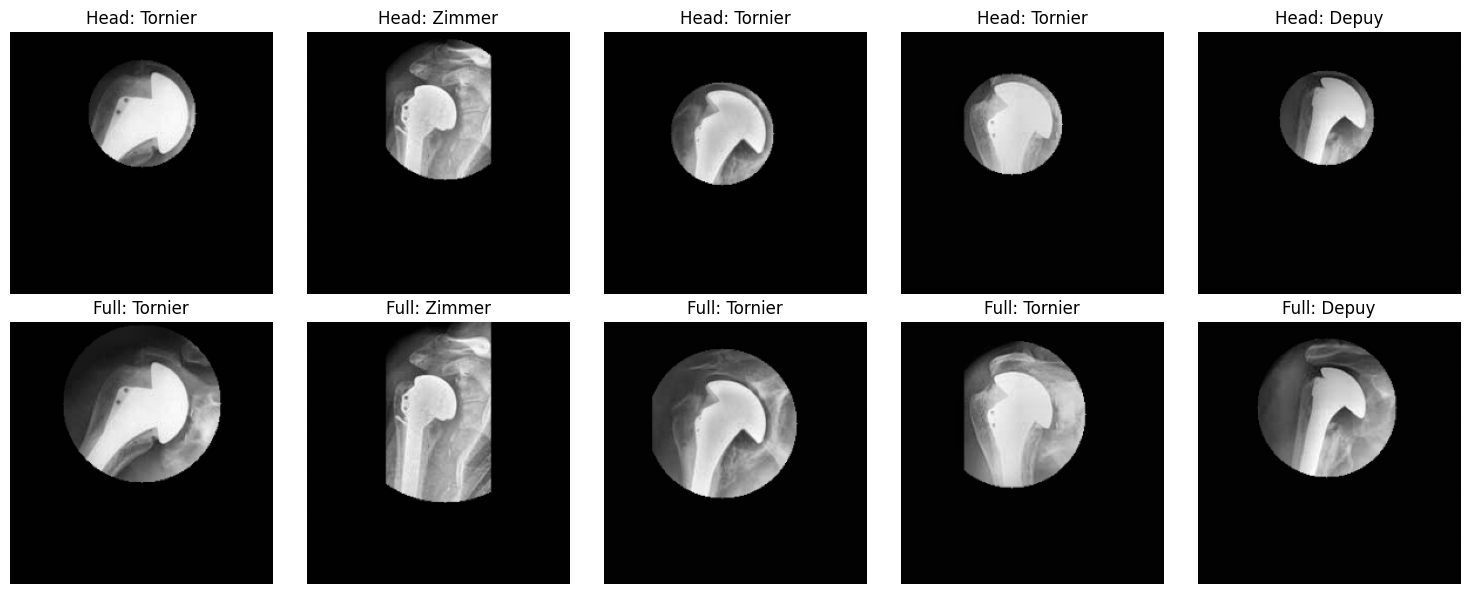


Initializing the dual-input orthopedic implant classifier...

Training the model...
Balanced class weights (smoothed): {0: np.float64(1.847645286154319), 1: np.float64(0.9815822174606855), 2: np.float64(2.0), 3: np.float64(1.3764944032233706)}
Balanced class weights (smoothed): {0: np.float64(1.847645286154319), 1: np.float64(0.9815822174606855), 2: np.float64(2.0), 3: np.float64(1.3764944032233706)}
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 88s 966ms/step - accuracy: 0.2948 - auc: 0.5300 - loss: 4.1302 - precision: 0.2959 - recall: 0.2429 - val_accuracy: 0.2150 - val_auc: 0.4635 - val_loss: 2.4806 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 871ms/step - accuracy: 0.3925 - auc: 0.6552 - loss: 3.2032 - precision: 0.4429 - recall: 0.3368 - val_accuracy: 0.3178 - val_auc: 0.6311 - val_loss: 2.3575 - val_precision: 0.3125 - val_recall: 0.0935 - learning_rate: 1.0000e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 46s 866

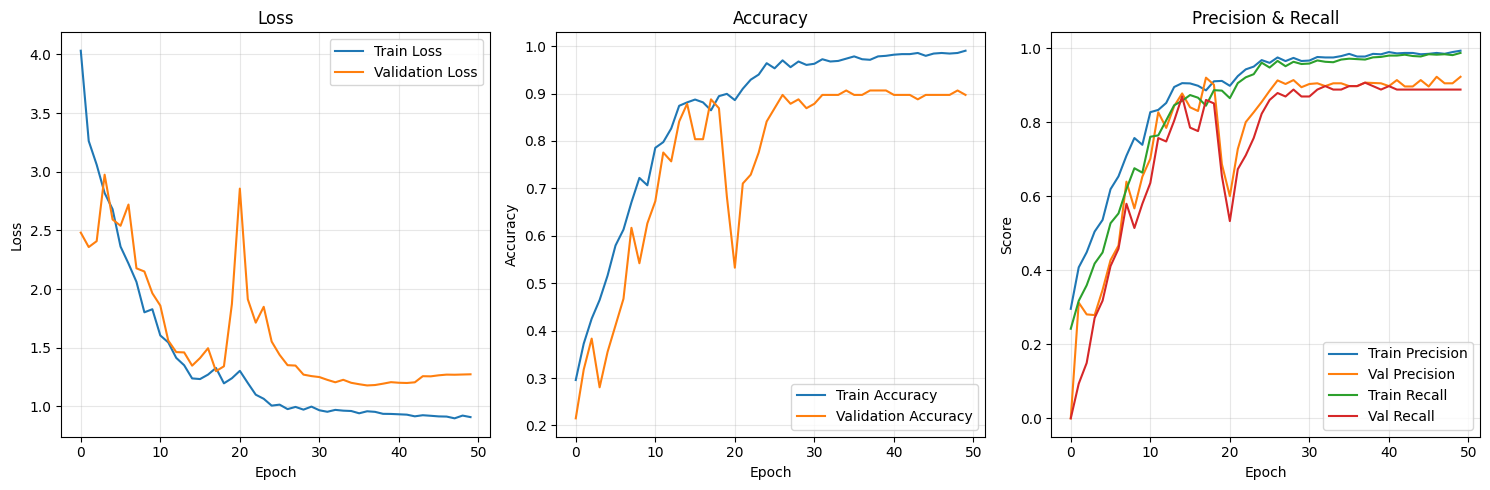


Evaluating the model on test data...
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


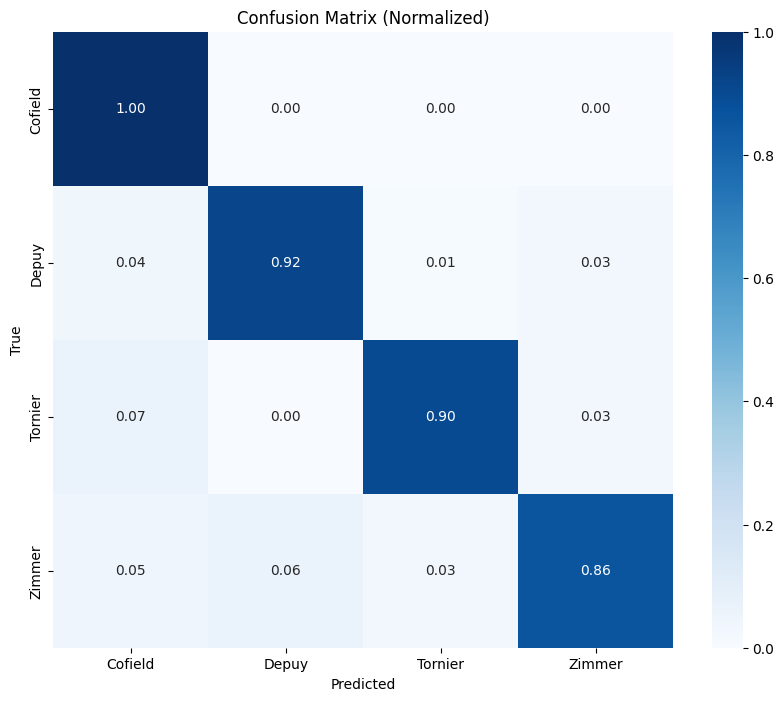

Classification Evaluation Results:
Accuracy: 0.913

Class-wise metrics:
Cofield:
  Precision: 0.778
  Recall: 1.000
  F1-score: 0.875
  Support: 35
Depuy:
  Precision: 0.966
  Recall: 0.919
  F1-score: 0.942
  Support: 124
Tornier:
  Precision: 0.900
  Recall: 0.900
  F1-score: 0.900
  Support: 30
Zimmer:
  Precision: 0.915
  Recall: 0.857
  F1-score: 0.885
  Support: 63

Visualizing classification results:


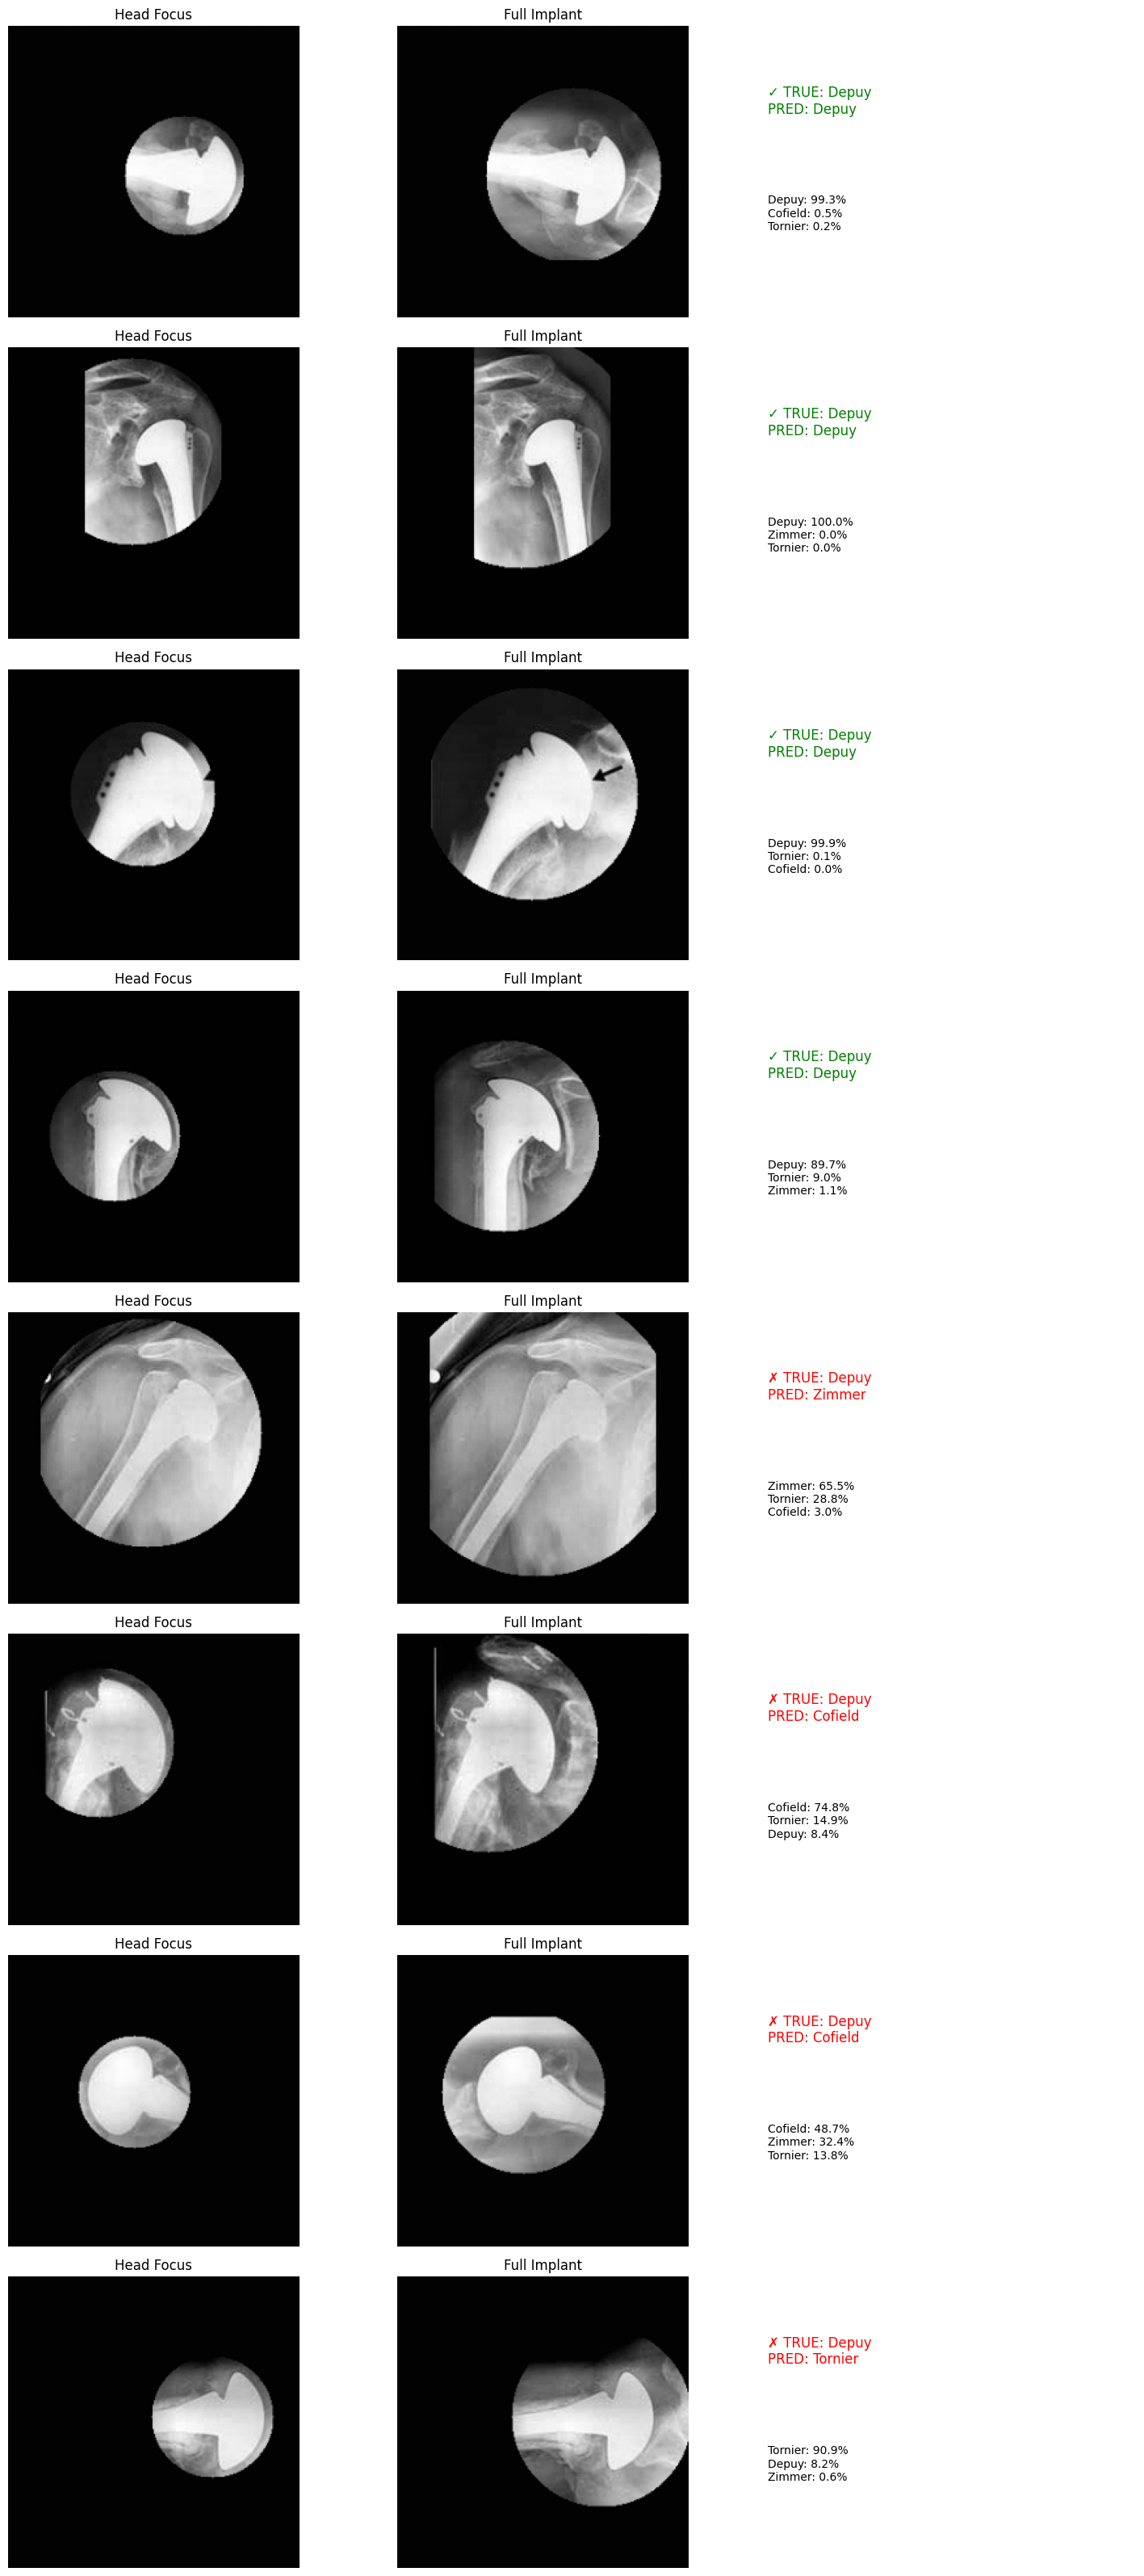


Training and evaluation complete!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from tqdm import tqdm
import random
import os

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def create_modified_hybrid_dataset(file_paths, labels, idx_to_manufacturer, img_size=(224, 224)):
    """
    Create a dataset with both head-focused and full-implant images using the new preprocessing.
    
    Args:
        file_paths: List of image paths
        labels: List of class labels
        idx_to_manufacturer: Mapping from label index to manufacturer name
        img_size: Target image size
        
    Returns:
        X_head: Head-focused images
        X_full: Full implant images
        y: One-hot encoded labels
    """
    X_head = []  # Head-focused images
    X_full = []  # Full implant images
    
    # Convert labels to manufacturer names for processing hints
    manufacturers = [idx_to_manufacturer[label] for label in labels]
    
    print("Processing images with advanced implant detection and enhancement...")
    for i, file_path in enumerate(tqdm(file_paths, desc="Creating hybrid dataset")):
        try:
            # Read the image
            img = cv2.imread(file_path)
            if img is None:
                print(f"Warning: Could not read image: {file_path}, skipping")
                continue
                
            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Get manufacturer hint for specialized processing
            manufacturer_hint = manufacturers[i] if i < len(manufacturers) else None
            
            # Detect implant with hybrid method
            detection_result, seed_coord, mask, mask_radius, detection_method = hybrid_implant_detection(img)
            
            # Extract head and full implant regions
            head_img, full_img = extract_implant_regions(img, seed_coord, mask)
            
            # Process head image with adaptive enhancement
            head_enhanced = enhance_implant_features_improved(head_img, enhance_method='adaptive')
            head_resized = cv2.resize(head_enhanced, img_size)
            head_normalized = head_resized.astype(np.float32) / 255.0
            
            # Process full implant image with adaptive enhancement
            full_enhanced = enhance_implant_features_improved(full_img, enhance_method='adaptive')
            full_resized = cv2.resize(full_enhanced, img_size)
            full_normalized = full_resized.astype(np.float32) / 255.0
            
            # Create multi-channel images (3 specialized channels)
            # Channel 1: Original processed image
            head_ch1 = head_normalized.copy()
            full_ch1 = full_normalized.copy()
            
            # Channel 2: Edge-enhanced version
            kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
            head_ch2 = cv2.filter2D(head_normalized, -1, kernel)
            head_ch2 = np.clip(head_ch2, 0, 1)  # Clip values to [0, 1]
            full_ch2 = cv2.filter2D(full_normalized, -1, kernel)
            full_ch2 = np.clip(full_ch2, 0, 1)  # Clip values to [0, 1]
            
            # Channel 3: Blurred version for texture
            head_ch3 = cv2.GaussianBlur(head_normalized, (5, 5), 0)
            full_ch3 = cv2.GaussianBlur(full_normalized, (5, 5), 0)
            
            # Stack channels
            head_multichannel = np.stack([head_ch1, head_ch2, head_ch3], axis=-1)
            full_multichannel = np.stack([full_ch1, full_ch2, full_ch3], axis=-1)
            
            # Add to lists
            X_head.append(head_multichannel)
            X_full.append(full_multichannel)
            
        except Exception as e:
            print(f"Error processing image {file_path}: {e}")
            # Create empty placeholder image
            empty_img = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
            X_head.append(empty_img)
            X_full.append(empty_img)
    
    # Convert lists to numpy arrays
    X_head = np.array(X_head)
    X_full = np.array(X_full)
    
    # One-hot encode labels
    y = tf.keras.utils.to_categorical(labels, num_classes=len(np.unique(labels)))
    
    return X_head, X_full, y

def main():
    """
    Main function for orthopedic implant classification with enhanced preprocessing.
    """
    print("\n" + "="*80)
    print("Orthopedic Implant Classification with Enhanced Preprocessing")
    print("="*80)
    
    # 1. Load the dataset
    print("\nLoading dataset...")
    data_dir = "data"  # Replace with your actual data directory
    dataset = load_dataset(data_dir)
    
    if dataset is None:
        print("Error: Failed to load dataset.")
        return
    
    # Extract data splits
    train_images, train_labels, train_paths = dataset['train_data']
    val_images, val_labels, val_paths = dataset['val_data']
    test_images, test_labels, test_paths = dataset['test_data']
    
    # Get mappings
    idx_to_manufacturer = dataset['idx_to_manufacturer']
    num_classes = dataset['num_classes']
    
    print(f"Dataset loaded successfully with {num_classes} classes")
    print(f"Training: {len(train_images)} images")
    print(f"Validation: {len(val_images)} images")
    print(f"Testing: {len(test_images)} images")
    
    # 2. Process data with enhanced preprocessing
    print("\nProcessing data with enhanced preprocessing...")
    X_head_train, X_full_train, y_train = create_modified_hybrid_dataset(
        train_paths, train_labels, idx_to_manufacturer)
    
    X_head_val, X_full_val, y_val = create_modified_hybrid_dataset(
        val_paths, val_labels, idx_to_manufacturer)
    
    X_head_test, X_full_test, y_test = create_modified_hybrid_dataset(
        test_paths, test_labels, idx_to_manufacturer)
    
    # 3. Visualize preprocessed samples
    print("\nVisualizing preprocessed samples:")
    visualize_preprocessed_samples(
        X_head_train[:10], X_full_train[:10], y_train[:10], 
        idx_to_manufacturer, num_samples=5)
    
    # 4. Initialize the classifier with the original model architecture
    print("\nInitializing the dual-input orthopedic implant classifier...")
    classifier = OrthopedicImplantClassifier(
        input_shape=(224, 224, 3),
        num_classes=num_classes,
        dropout_rate=0.5,
        l2_reg=0.001,
        use_attention=True
    )
    
    # 5. Create callbacks for training with early stopping and learning rate reduction
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=7,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    # 6. Train the model with the processed data
    print("\nTraining the model...")
    batch_size = 16
    epochs = 50
    
    # Compute class weights to handle imbalanced classes
    use_class_weights = True
    if use_class_weights:
        class_weights = classifier.compute_balanced_class_weights(y_train)
    else:
        class_weights = None
    
    # Create TF datasets for training with mixup and cutmix
    train_dataset = tf.data.Dataset.from_tensor_slices(
        ({'head_input': X_head_train, 'full_input': X_full_train}, y_train)
    ).shuffle(buffer_size=len(X_head_train)).batch(batch_size)
    
    val_dataset = tf.data.Dataset.from_tensor_slices(
        ({'head_input': X_head_val, 'full_input': X_full_val}, y_val)
    ).batch(batch_size)
    
    # Train with mixup and cutmix augmentation
    history = classifier.train(
        X_head_train, X_full_train, y_train,
        X_head_val, X_full_val, y_val,
        batch_size=batch_size,
        epochs=epochs,
        use_class_weights=use_class_weights,
        checkpoint_path=None,  # Not saving the model as requested
        mixup_alpha=0.2,       # Apply mixup augmentation
        apply_cutmix=True      # Apply cutmix augmentation
    )
    
    # 7. Evaluate the model
    print("\nEvaluating the model on test data...")
    metrics, predictions = classifier.evaluate(
        X_head_test, X_full_test, y_test, idx_to_manufacturer
    )
    
    # 8. Visualize predictions
    print("\nVisualizing classification results:")
    classifier.visualize_predictions(
        X_head_test, X_full_test, y_test, predictions,
        idx_to_manufacturer, num_samples=8
    )
    
    print("\nTraining and evaluation complete!")
    return classifier, metrics, history

if __name__ == "__main__":
    main()